In [2]:
import numpy as np
import pandas as pd
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
df = pd.read_csv('data/iris.csv')

In [10]:
X = df[["sepal_length","sepal_width","petal_length","petal_width"]]
y = df["species"]
#X = df.drop["species", axis="column"]
# 125 training and 25 test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=25, random_state=1, stratify=y)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(125, 4)
(25, 4)
(125,)
(25,)


In [11]:
tree = DecisionTreeClassifier()
tree.fit(X_train,y_train)


DecisionTreeClassifier()

In [12]:
tree.get_depth()

6

In [13]:
y_hat = tree.predict(X_test)

In [14]:
# Model Accuracy, how often is the classifier correct?
print("Accuracy:", accuracy_score(y_test, y_hat))
# confusion matrix
cm = confusion_matrix(y_test, y_hat)
print(cm)

Accuracy: 0.96
[[8 0 0]
 [0 9 0]
 [0 1 7]]


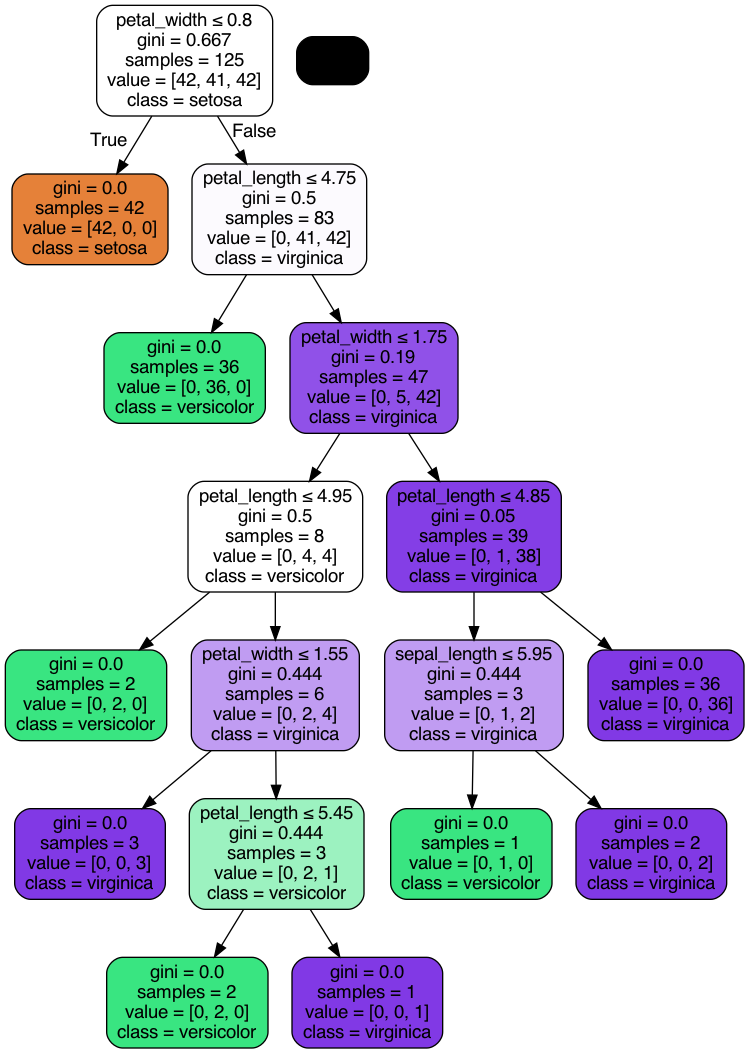

In [15]:
from sklearn.tree import export_graphviz
from io import StringIO
from IPython.display import Image
import pydotplus
feature_names = ["sepal_length","sepal_width","petal_length","petal_width"]
target_names = ["setosa", "versicolor", "virginica"]
dot_data = StringIO()
export_graphviz(tree, out_file=dot_data,
 filled=True, rounded=True,
 special_characters=True, feature_names = feature_names, 
 class_names = target_names)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
#graph.write_png('plots/iris.png')
Image(graph.create_png())